In [1]:
!conda env list



# conda environments:
#
# * -> active
# + -> frozen
base                 *   /home/sayan/miniconda3
pytorch-env              /home/sayan/miniconda3/envs/pytorch-env



In [2]:
import os
print(os.environ['CONDA_DEFAULT_ENV'])

base


In [3]:
import datetime 
from functools import partial 
from glob import glob
import json 
import math 
import multiprocessing 
import os
from pathlib import Path
import random
from typing import Any, Dict, Optional 

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from distinctipy import distinctipy
from PIL import Image, ImageDraw
from tqdm.auto import tqdm

In [5]:
import pandas as pd
pd.set_option('max_colwidth', None)  # Do not truncate the contents of cells in the DataFrame
pd.set_option('display.max_rows', None)  # Display all rows in the DataFrame
pd.set_option('display.max_columns', None)  # Display all columns in the DataFrame


In [6]:
import torch
from torch.amp import autocast
from torch.cuda.amp import GradScaler
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchtnt.utils import get_module_summary
import torchvision
torchvision.disable_beta_transforms_warning()
from torchvision.tv_tensors import BoundingBoxes, Mask
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
import torchvision.transforms.v2  as transforms
from torchvision.transforms.v2 import functional as TF

# Import Mask R-CNN
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2, MaskRCNN
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor


In [7]:
seed = 1234 
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
set_seed(seed) 

In [8]:
def get_torch_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

device = get_torch_device()
dtype = torch.float32
device, dtype

(device(type='cuda'), torch.float32)

In [9]:
# The name for the project
project_name = f"pytorch-mask-r-cnn-instance-segmentation"

# The path for the project folder
project_dir = Path(f"./{project_name}/")

# Create the project directory if it does not already exist
project_dir.mkdir(parents=True, exist_ok=True)

# Define path to store datasets
dataset_dir = Path("./Datasets/")
# Create the dataset directory if it does not exist
dataset_dir.mkdir(parents=True, exist_ok=True)

pd.Series({
    "Project Directory:": project_dir, 
    "Dataset Directory:": dataset_dir
}).to_frame().style.hide(axis='columns')

Project Directory:,pytorch-mask-r-cnn-instance-segmentation
Dataset Directory:,Datasets


In [10]:
# Set the name of the dataset
dataset_name = 'pytorch-for-information-extraction'

# Construct the GitHub repository name 
gh_repo = f'cj-mills/{dataset_name}'

# Create the path to the directory where the dataset will be extracted
dataset_path = Path(f'{dataset_dir}/{dataset_name}/code/datasets/detection/student-id/')

pd.Series({
    "GitHub Repository:": gh_repo, 
    "Dataset Path:": dataset_path
}).to_frame().style.hide(axis='columns')

GitHub Repository:,cj-mills/pytorch-for-information-extraction
Dataset Path:,Datasets/pytorch-for-information-extraction/code/datasets/detection/student-id


In [11]:
#Dataset
!git clone {f 'https://github.com/cj-mills/pytorch-for-information-extraction'} {Datasets/pytorch-for-information-extraction/code/datasets/detection/student-id}

fatal: Too many arguments.

usage: git clone [<options>] [--] <repo> [<dir>]

    -v, --verbose         be more verbose
    -q, --quiet           be more quiet
    --progress            force progress reporting
    --reject-shallow      don't clone shallow repository
    -n, --no-checkout     don't create a checkout
    --bare                create a bare repository
    --mirror              create a mirror repository (implies bare)
    -l, --local           to clone from a local repository
    --no-hardlinks        don't use local hardlinks, always copy
    -s, --shared          setup as shared repository
    --recurse-submodules[=<pathspec>]
                          initialize submodules in the clone
    --recursive ...       alias of --recurse-submodules
    -j, --jobs <n>        number of submodules cloned in parallel
    --template <template-directory>
                          directory from which templates will be used
    --reference <repo>    reference repository
    --refere

In [12]:
# import os
# print(os.getcwd())

In [13]:
# def get_img_files(dataset_path):
#     image_data = []

#     for filename in os.listdir(dataset_path):
#         if filename.endswith(".jpg") or filename.endswith(".png"):
#             img_path = os.path.join(dataset_path, filename)
#             img = Image.open(img_path).convert("RGB")
#             img_array = np.array(img)
#             image_data.append(img_array)
#     image_data = np.array(image_data)
#     return image_data

def get_img_files(folder_path):
    folder_path = Path(folder_path)
    img_files = [f for f in folder_path.glob('*') 
                 if f.suffix.lower() in ['.jpg', '.png']]
    return sorted(img_files)

In [14]:
import os
for item in os.listdir('Datasets'):
    print(item)

pytorch-for-information-extraction


In [15]:
img_file_paths = get_img_files(dataset_path)

# Get a list of JSON files in the dataset
annotation_file_paths = list(dataset_path.glob('*.json'))

# Display the names of the folders using a Pandas DataFrame
pd.DataFrame({"Image File": [file.name for file in img_file_paths], 
              "Annotation File":[file.name for file in annotation_file_paths]}).head()

,Image File,Annotation File
0,10001.jpg,10023.json
1,10002.jpg,10026.json
2,10003.jpg,10144.json
3,10004.jpg,10111.json
4,10005.jpg,10054.json


In [16]:
img_dict = {file.stem : file for file in img_file_paths}
print(f"Number of Images: {len(img_dict)}")

pd.DataFrame.from_dict(img_dict, orient = 'index').head()

Number of Images: 150


,0
10001,Datasets/pytorch-for-information-extraction/code/datasets/detection/student-id/10001.jpg
10002,Datasets/pytorch-for-information-extraction/code/datasets/detection/student-id/10002.jpg
10003,Datasets/pytorch-for-information-extraction/code/datasets/detection/student-id/10003.jpg
10004,Datasets/pytorch-for-information-extraction/code/datasets/detection/student-id/10004.jpg
10005,Datasets/pytorch-for-information-extraction/code/datasets/detection/student-id/10005.jpg


In [17]:
cls_dataframes = (pd.read_json(f, orient = 'index').transpose() for f in tqdm(annotation_file_paths))
annotation_df = pd.concat(cls_dataframes, ignore_index = False)

annotation_df['index'] = annotation_df.apply(lambda row: row['imagePath'].split('.')[0], axis = 1)
annotation_df = annotation_df.set_index('index')

# Keep only the rows that correspond to the filenames in the 'img_dict' dictionary
annotation_df = annotation_df.loc[list(img_dict.keys())]

# Print the first 5 rows of the DataFrame
annotation_df.head()


  0%|          | 0/150 [00:00<?, ?it/s]

,version,flags,shapes,lineColor,fillColor,imagePath,imageData,imageHeight,imageWidth
index,,,,,,,,,
10001,3.21.1,{},"[{'label': 'student_id', 'line_color': None, 'fill_color': None, 'points': [[19.190476190476204, 244.76190476190476], [23.0, 233.33333333333331], [385.8571428571428, 132.38095238095238], [400.1428571428571, 135.23809523809524], [468.71428571428567, 353.3333333333333], [466.80952380952374, 362.85714285714283], [97.28571428571428, 478.0952380952381], [81.09523809523807, 474.2857142857143]], 'shape_type': 'polygon', 'flags': {}}]","[0, 255, 0, 128]","[255, 0, 0, 128]",10001.jpg,,640,480
10002,3.21.1,{},"[{'label': 'student_id', 'line_color': None, 'fill_color': None, 'points': [[21.095238095238102, 183.33333333333334], [231.41269841269843, 88.09523809523809], [450.46031746031747, 347.6190476190476], [475.06349206349205, 376.1904761904762], [478.2380952380952, 388.8888888888889], [301.25396825396825, 532.5396825396825], [271.0952380952381, 556.3492063492064], [255.22222222222223, 541.2698412698413], [242.52380952380952, 534.9206349206349], [25.85714285714286, 199.20634920634922]], 'shape_type': 'polygon', 'flags': {}}]","[0, 255, 0, 128]","[255, 0, 0, 128]",10002.jpg,,640,480
10003,3.21.1,{},"[{'label': 'student_id', 'line_color': None, 'fill_color': None, 'points': [[138.23809523809524, 71.42857142857143], [407.7619047619047, 31.428571428571427], [418.2380952380952, 39.047619047619044], [422.04761904761904, 539.047619047619], [407.7619047619047, 552.3809523809524], [112.52380952380952, 519.047619047619], [98.23809523809524, 505.71428571428567]], 'shape_type': 'polygon', 'flags': {}}]","[0, 255, 0, 128]","[255, 0, 0, 128]",10003.jpg,,640,480
10004,3.21.1,{},"[{'label': 'student_id', 'line_color': None, 'fill_color': None, 'points': [[119.20529801324503, 218.54304635761588], [440.3973509933775, 184.7682119205298], [445.0331125827814, 190.72847682119206], [391.3907284768212, 366.2251655629139], [384.7682119205298, 372.18543046357615], [250.33112582781456, 401.3245033112583], [82.11920529801324, 446.3576158940397], [76.82119205298014, 441.72185430463577], [49.66887417218544, 239.73509933774835], [107.28476821192052, 228.47682119205297]], 'shape_type': 'polygon', 'flags': {}}]","[0, 255, 0, 128]","[255, 0, 0, 128]",10004.jpg,,640,480
10005,3.21.1,{},"[{'label': 'student_id', 'line_color': None, 'fill_color': None, 'points': [[41.18840579710144, 218.8405797101449], [41.18840579710144, 209.42028985507244], [52.78260869565216, 201.44927536231882], [224.52173913043475, 142.75362318840578], [359.30434782608694, 89.85507246376811], [367.99999999999994, 92.02898550724638], [462.2028985507246, 275.3623188405797], [369.4492753623188, 348.5507246376811], [199.88405797101444, 472.463768115942], [191.91304347826082, 471.01449275362313]], 'shape_type': 'polygon', 'flags': {}}]","[0, 255, 0, 128]","[255, 0, 0, 128]",10005.jpg,,640,480


In [18]:
shapes_df = annotation_df['shapes'].explode().to_frame().shapes.apply(pd.Series)
class_names = shapes_df['label'].unique().tolist()

pd.DataFrame(class_names)

,0
0,student_id


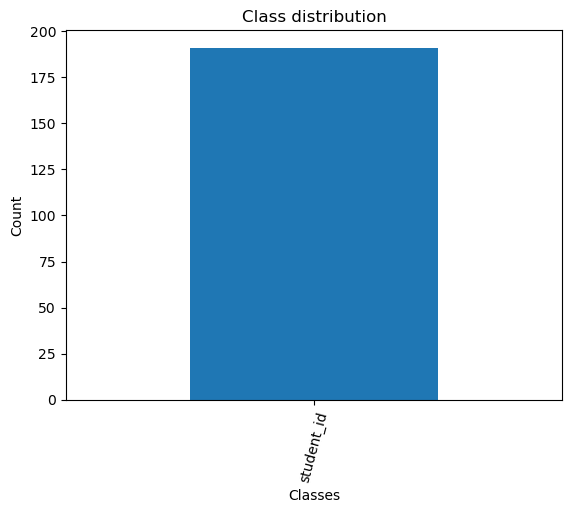

In [19]:
class_counts = shapes_df['label'].value_counts()

# Plot the distribution
class_counts.plot(kind='bar')
plt.title('Class distribution')
plt.ylabel('Count')
plt.xlabel('Classes')
plt.xticks(range(len(class_counts.index)), class_names, rotation=75)  # Set the x-axis tick labels
plt.show()

In [20]:
#adding a background class
class_names = ['background']+class_names
pd.DataFrame(class_names)


,0
0,background
1,student_id


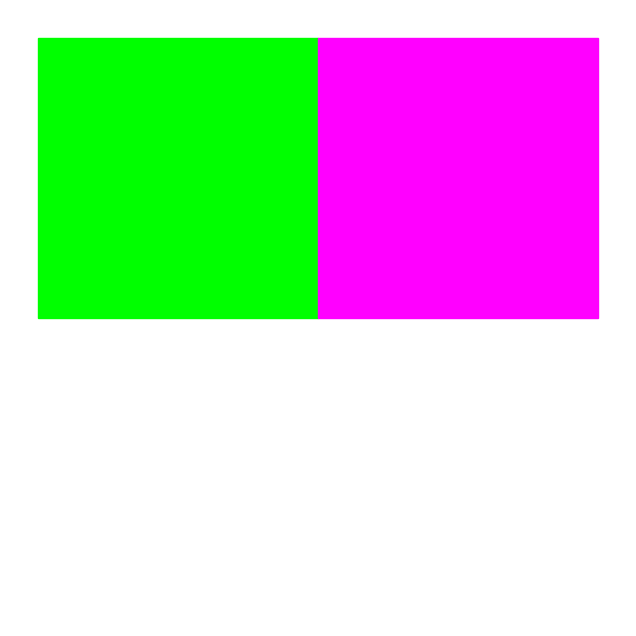

In [21]:
# Generate a list of colors with a length equal to the number of labels
colors = distinctipy.get_colors(len(class_names))

int_colors = [tuple(int(c*255) for c in color) for color in colors]
distinctipy.color_swatch(colors)

In [22]:
# # Set the name of the font file
# font_file = 'KFOlCnqEu92Fr1MmEU9vAw.ttf'

# # Download the font file
# download_file(f"https://fonts.gstatic.com/s/roboto/v30/{font_file}", "./")

In [23]:
draw_bboxes = partial(draw_bounding_boxes, fill=False, width=2, font_size=25)


Image Dims: (480, 640)


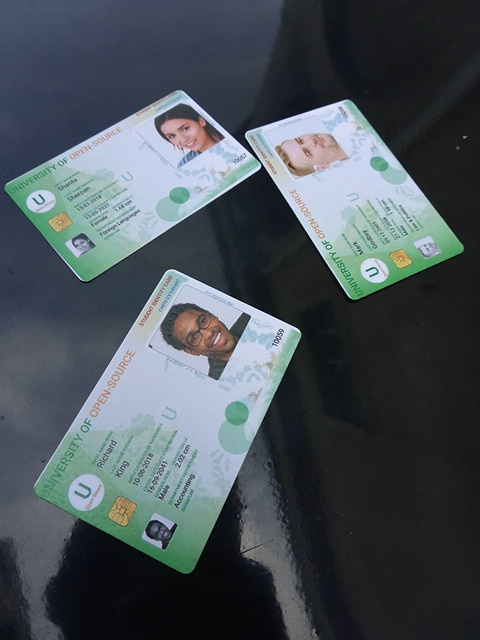

In [24]:
file_id = list(img_dict.keys())[56]
sample_img = Image.open(img_dict[file_id]).convert("RGB")

print(f"Image Dims: {sample_img.size}")
sample_img

In [25]:
annotation_df.loc[file_id].to_frame()


,10057
version,3.21.1
flags,{}
shapes,"[{'label': 'student_id', 'line_color': None, 'fill_color': None, 'points': [[4.703296703296701, 186.8131868131868], [172.28571428571428, 91.20879120879121], [177.23076923076923, 89.56043956043956], [183.82417582417582, 92.85714285714285], [260.19780219780216, 161.53846153846152], [248.65934065934067, 173.07692307692307], [99.75824175824175, 273.6263736263736], [88.2197802197802, 280.7692307692308], [83.27472527472527, 280.7692307692308], [35.472527472527474, 225.82417582417582]], 'shape_type': 'polygon', 'flags': {}}, {'label': 'student_id', 'line_color': None, 'fill_color': None, 'points': [[245.36263736263737, 134.06593406593407], [346.46153846153845, 100.0], [352.5054945054945, 101.64835164835165], [465.1428571428571, 248.9010989010989], [461.8461538461538, 252.1978021978022], [356.35164835164835, 300.5494505494505], [350.3076923076923, 297.8021978021978]], 'shape_type': 'polygon', 'flags': {}}, {'label': 'student_id', 'line_color': None, 'fill_color': None, 'points': [[33.27472527472527, 489.010989010989], [159.64835164835165, 281.3186813186813], [166.7912087912088, 271.97802197802196], [172.28571428571428, 270.3296703296703], [297.010989010989, 330.2197802197802], [300.3076923076923, 335.16483516483515], [299.2087912087912, 340.65934065934067], [223.38461538461536, 506.5934065934066], [192.6153846153846, 571.4285714285714], [184.9230769230769, 574.1758241758241], [172.28571428571428, 569.2307692307692], [47.56043956043956, 501.0989010989011], [36.021978021978015, 496.15384615384613]], 'shape_type': 'polygon', 'flags': {}}]"
lineColor,"[0, 255, 0, 128]"
fillColor,"[255, 0, 0, 128]"
imagePath,10057.jpg
imageData,
imageHeight,640
imageWidth,480


In [26]:
def create_polygon_mask(image_size, vertices):
    """
    Create a grayscale image with a white polygonal area on a black background.

    Parameters:
    - image_size (tuple): A tuple representing the dimensions (width, height) of the image.
    - vertices (list): A list of tuples, each containing the x, y coordinates of a vertex
                        of the polygon. Vertices should be in clockwise or counter-clockwise order.

    Returns:
    - PIL.Image.Image: A PIL Image object containing the polygonal mask.
    """

    # Create a new black image with the given dimensions
    mask_img = Image.new('L', image_size, 0)
    
    # Draw the polygon on the image. The area inside the polygon will be white (255).
    ImageDraw.Draw(mask_img, 'L').polygon(vertices, fill=(255))

    # Return the image with the drawn polygon
    return mask_img

/home/sayan/.local/lib/python3.10/site-packages/torchvision/utils.py:375: UserWarning: Argument 'font_size' will be ignored since 'font' is not set.
  warnings.warn("Argument 'font_size' will be ignored since 'font' is not set.")


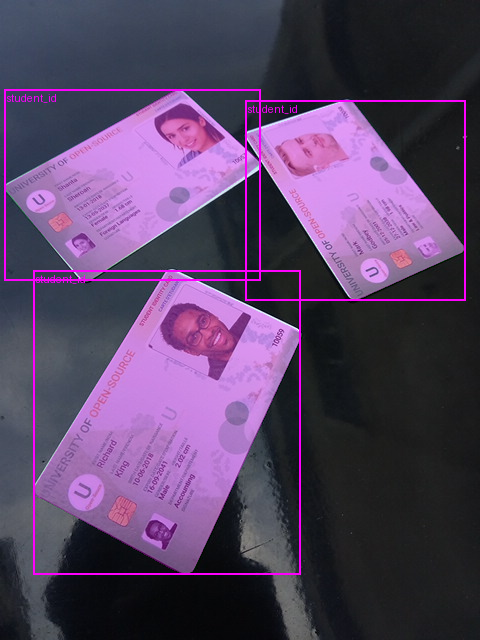

In [27]:
def tensor_to_pil(tensor_img):
    return transforms.ToPILImage()(tensor_img)

labels = [shape['label'] for shape in annotation_df.loc[file_id]['shapes']]
shape_points = [shape['points'] for shape in annotation_df.loc[file_id]['shapes']]
xy_coords = [[tuple(p) for p in points] for points in shape_points]
mask_imgs = [create_polygon_mask(sample_img.size, xy) for xy in xy_coords]
masks = torch.concat([Mask(transforms.PILToTensor()(mask_img), dtype=torch.bool) for mask_img in mask_imgs])
bboxes = torchvision.ops.masks_to_boxes(masks)

annotated_tensor = draw_segmentation_masks(
    image=transforms.PILToTensor()(sample_img), 
    masks=masks, 
    alpha=0.3, 
    colors=[int_colors[i] for i in [class_names.index(label) for label in labels]]
)

# Annotate the sample image with labels and bounding boxes
annotated_tensor = draw_bboxes(
    image=annotated_tensor, 
    boxes=bboxes, 
    labels=labels, 
    colors=[int_colors[i] for i in [class_names.index(label) for label in labels]]
)

tensor_to_pil(annotated_tensor)

In [28]:
model = maskrcnn_resnet50_fpn_v2(weights = 'DEFAULT')

in_features_box = model.roi_heads.box_predictor.cls_score.in_features
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels

dim_reduced = model.roi_heads.mask_predictor.conv5_mask.out_channels
model.roi_heads.box_predictor = FastRCNNPredictor(in_channels=in_features_box, num_classes=len(class_names))
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_channels=in_features_mask, dim_reduced=dim_reduced, num_classes=len(class_names))

model.to(device=device, dtype=dtype);
model.device = device
model_name = "maskrcnn_resnet50_fpn_v2"


In [29]:
img_keys = list(img_dict.keys())
random.shuffle(img_keys)

train_pct = 0.8
val_pct = 0.2 

train_split = int(len(img_keys)*train_pct)
val_split = int(len(img_keys)*(train_pct+val_pct))
train_keys = img_keys[:train_split]
val_keys = img_keys[train_split:]

pd.Series({
    "Training Samples:" : len(train_keys),
    "Validation Samples" : len(val_keys)
}). to_frame().style.hide(axis = 'columns')


Training Samples:,120
Validation Samples,30


In [77]:
class StudentIDDataset(Dataset):
    """
    This class represents a PyTorch Dataset for a collection of images and their annotations.
    """
    def __init__(self, img_keys, annotation_df, img_dict, class_to_idx, transforms=None):
        """
        Constructor for the HagridDataset class.
        """
        super(Dataset, self).__init__()
        
        self._img_keys = img_keys  # List of image keys
        self._annotation_df = annotation_df  # DataFrame containing annotations
        self._img_dict = img_dict  # Dictionary mapping image keys to image paths
        self._class_to_idx = class_to_idx  # Dictionary mapping class names to class indices
        self._transforms = transforms  # Image transforms to be applied
        
    def __len__(self):
        """
        Returns the length of the dataset.

        Returns:
        int: The number of items in the dataset.
        """
        return len(self._img_keys)
        
    def __getitem__(self, index):
        """
        Fetch an item from the dataset at the specified index.

        Parameters:
        index (int): Index of the item to fetch from the dataset.

        Returns:
        tuple: A tuple containing the image and its associated target (annotations).
        """
        # Retrieve the key for the image at the specified index
        img_key = self._img_keys[index]
        # Get the annotations for this image
        annotation = self._annotation_df.loc[img_key]
        # Load the image and its target (segmentation masks, bounding boxes and labels)
        image, target = self._load_image_and_target(annotation)
        
        # Apply the transformations, if any
        if self._transforms:
            image, target = self._transforms(image, target)
        image = transforms.Resize((640, 480))(image)
        
        return image, target

    def _load_image_and_target(self, annotation):
        """
        Load an image and its target (bounding boxes and labels).

        Parameters:
        annotation (pandas.Series): The annotations for an image.

        Returns:
        tuple: A tuple containing the image and a dictionary with 'boxes' and 'labels' keys.
        """
        # Retrieve the file path of the image
        filepath = self._img_dict[annotation.name]
        # Open the image file and convert it to RGB
        image = Image.open(filepath).convert('RGB')
        
        # Convert the class labels to indices
        labels = [shape['label'] for shape in annotation['shapes']]
        labels = torch.Tensor([self._class_to_idx[label] for label in labels])
        labels = labels.to(dtype=torch.int64)

        # Convert polygons to mask images
        shape_points = [shape['points'] for shape in annotation['shapes']]
        xy_coords = [[tuple(p) for p in points] for points in shape_points]
        mask_imgs = [create_polygon_mask(image.size, xy) for xy in xy_coords]
        masks = Mask(torch.concat([Mask(transforms.PILToTensor()(mask_img), dtype=torch.bool) for mask_img in mask_imgs]))

        # Generate bounding box annotations from segmentation masks
        bboxes = BoundingBoxes(data=torchvision.ops.masks_to_boxes(masks), format='xyxy', canvas_size=image.size[::-1])
                
        return image, {'masks': masks,'boxes': bboxes, 'labels': labels}

In [78]:
# Create a mapping from class names to class indices
class_to_idx = {c: i for i, c in enumerate(class_names)}

# Instantiate the datasets using the defined transformations
train_dataset = StudentIDDataset(train_keys, annotation_df, img_dict, class_to_idx)
valid_dataset = StudentIDDataset(val_keys, annotation_df, img_dict, class_to_idx)

# Print the number of samples in the training and validation datasets
pd.Series({
    'Training dataset size:': len(train_dataset),
    'Validation dataset size:': len(valid_dataset)}
).to_frame().style.hide(axis='columns')

Training dataset size:,120
Validation dataset size:,30


In [79]:
def run_epoch(model, dataloader, optimizer, lr_scheduler, device, scaler, epoch_id, is_training):
    model.train()

    epoch_loss = 0
    progress_bar = tqdm(total = len(dataloader), desc = "Train" if is_training else "Eval")

    for batch_id, (inputs, targets) in enumerate(dataloader):
        # Move inputs and targets to the specified device
        inputs = torch.stack(inputs).to(device)
        
        # Forward pass with Automatic Mixed Precision (AMP) context manager
        with autocast(torch.device(device).type):
            if is_training:
                losses = model(inputs.to(device), move_data_to_device(targets, device))
            else:
                with torch.no_grad():
                    losses = model(inputs.to(device), move_data_to_device(targets, device))
        
            # Compute the loss
            loss = sum([loss for loss in losses.values()])  # Sum up the losses

        # If in training mode, backpropagate the error and update the weights
        if is_training:
            if scaler:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                old_scaler = scaler.get_scale()
                scaler.update()
                new_scaler = scaler.get_scale()
                if new_scaler >= old_scaler:
                    lr_scheduler.step()
            else:
                loss.backward()
                optimizer.step()
                lr_scheduler.step()
                
            optimizer.zero_grad()

        # Update the total loss
        loss_item = loss.item()
        epoch_loss += loss_item
        
        # Update the progress bar
        progress_bar_dict = dict(loss=loss_item, avg_loss=epoch_loss/(batch_id+1))
        if is_training:
            progress_bar_dict.update(lr=lr_scheduler.get_last_lr()[0])
        progress_bar.set_postfix(progress_bar_dict)
        progress_bar.update()

        # If loss is NaN or infinity, stop training
        if is_training:
            stop_training_message = f"Loss is NaN or infinite at epoch {epoch_id}, batch {batch_id}. Stopping training."
            assert not math.isnan(loss_item) and math.isfinite(loss_item), stop_training_message

    # Cleanup and close the progress bar 
    progress_bar.close()
    
    # Return the average loss for this epoch
    return epoch_loss / (batch_id + 1)
    

In [80]:
def train_loop(model, 
               train_dataloader, 
               valid_dataloader, 
               optimizer,  
               lr_scheduler, 
               device, 
               epochs, 
               checkpoint_path, 
               use_scaler=False):
        scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' and use_scaler else None
        best_loss = float('inf')  # Initialize the best validation loss
    
        # Loop over the epochs
        for epoch in tqdm(range(epochs), desc="Epochs"):
            # Run a training epoch and get the training loss
            train_loss = run_epoch(model, train_dataloader, optimizer, lr_scheduler, device, scaler, epoch, is_training=True)
            # Run an evaluation epoch and get the validation loss
            with torch.no_grad():
                valid_loss = run_epoch(model, valid_dataloader, None, None, device, scaler, epoch, is_training=False)
    
            # If the validation loss is lower than the best validation loss seen so far, save the model checkpoint
            if valid_loss < best_loss:
                best_loss = valid_loss
                torch.save(model.state_dict(), checkpoint_path)
    
                # Save metadata about the training process
                training_metadata = {
                    'epoch': epoch,
                    'train_loss': train_loss,
                    'valid_loss': valid_loss, 
                    'learning_rate': lr_scheduler.get_last_lr()[0],
                    'model_architecture': model.name
                }
                with open(Path(checkpoint_path.parent/'training_metadata.json'), 'w') as f:
                    json.dump(training_metadata, f)
    
        # If the device is a GPU, empty the cache
        if device.type != 'cpu':
            getattr(torch, device.type).empty_cache()

In [34]:
# timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# # Create a directory to store the checkpoints if it does not already exist
# checkpoint_dir = Path(project_dir/f"{timestamp}")

# # Create the checkpoint directory if it does not already exist
# checkpoint_dir.mkdir(parents=True, exist_ok=True)

# # The model checkpoint path
# checkpoint_path = checkpoint_dir/f"{model.name}.pth"

# print(checkpoint_path)

AttributeError: 'MaskRCNN' object has no attribute 'name'

In [81]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
lr = 5e-4

# Number of training epochs
epochs = 40

# AdamW optimizer; includes weight decay for regularization
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

# Learning rate scheduler; adjusts the learning rate during training
lr_scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, 
                                                   max_lr=lr, 
                                                   total_steps=epochs*len(train_dataloader))

In [82]:
train_loop(model=model, 
           train_dataloader=train_dataloader,
           valid_dataloader=valid_dataloader,
           optimizer=optimizer, 
           lr_scheduler=lr_scheduler, 
           device=torch.device(device), 
           epochs=epochs,
           checkpoint_path = None,
           use_scaler=True)

/tmp/ipykernel_919/871701301.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' and use_scaler else None


Epochs:   0%|          | 0/40 [00:00<?, ?it/s]

Train:   0%|          | 0/4 [00:00<?, ?it/s]

RuntimeError: stack expects each tensor to be equal size, but got [1, 640, 480] at entry 0 and [1, 480, 640] at entry 1